## **1. Data Cleaning**

In [18]:
import pandas as pd
import numpy as np

In [19]:
pd.set_option("display.max_columns",None)
pd.set_option("display.max_rows",None)

In [20]:
control =pd.read_csv(r'C:\Data science work\Projects\ab-testing project2\Data\control_group.csv',sep =';')
test = pd.read_csv(r'C:\Data science work\Projects\ab-testing project2\Data\test_group.csv',sep=';')

**🔹 Clean Column Names**

In [21]:
def cleaned_columns(df):
    df.columns = (
        df.columns
        .str.lower()
        .str.replace(" ","_")
        .str.replace("#", "")
        .str.replace("[", "",regex = False)
        .str.replace("]", "", regex = False)
        .str.replace("__","_")
        .str.replace("_of_", "")
        .str.replace("website_", "")
        
    )

    return df

control = cleaned_columns(control)
test = cleaned_columns(test) 

print (control.columns)
print (test.columns)

Index(['campaign_name', 'date', 'spend_usd', 'impressions', 'reach', 'clicks',
       'searches', 'view_content', 'add_to_cart', 'purchase'],
      dtype='str')
Index(['campaign_name', 'date', 'spend_usd', 'impressions', 'reach', 'clicks',
       'searches', 'view_content', 'add_to_cart', 'purchase'],
      dtype='str')


**🔹 Add Group Column & Combine Both Datasets (again cleanly)**

In [22]:
control['group'] ='control' # adding a new column called group which used to categorize the data 
test['group'] = 'test'     # from control csv and test csv into 2 groups control and test

df = pd.concat([control, test],ignore_index=True) # were adding the new column 'group to main data frame called df

print(df.head())

      campaign_name       date  spend_usd  impressions     reach  clicks  \
0  Control Campaign  1.08.2019       2280      82702.0   56930.0  7016.0   
1  Control Campaign  2.08.2019       1757     121040.0  102513.0  8110.0   
2  Control Campaign  3.08.2019       2343     131711.0  110862.0  6508.0   
3  Control Campaign  4.08.2019       1940      72878.0   61235.0  3065.0   
4  Control Campaign  5.08.2019       1835          NaN       NaN     NaN   

   searches  view_content  add_to_cart  purchase    group  
0    2290.0        2159.0       1819.0     618.0  control  
1    2033.0        1841.0       1219.0     511.0  control  
2    1737.0        1549.0       1134.0     372.0  control  
3    1042.0         982.0       1183.0     340.0  control  
4       NaN           NaN          NaN       NaN  control  


**🔹 Check Data Info**

Any missing values?

Data types (numbers vs object)

Strange values?

In [23]:
print(df.info())

print(df.describe())

<class 'pandas.DataFrame'>
RangeIndex: 60 entries, 0 to 59
Data columns (total 11 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   campaign_name  60 non-null     str    
 1   date           60 non-null     str    
 2   spend_usd      60 non-null     int64  
 3   impressions    59 non-null     float64
 4   reach          59 non-null     float64
 5   clicks         59 non-null     float64
 6   searches       59 non-null     float64
 7   view_content   59 non-null     float64
 8   add_to_cart    59 non-null     float64
 9   purchase       59 non-null     float64
 10  group          60 non-null     str    
dtypes: float64(7), int64(1), str(3)
memory usage: 5.3 KB
None
         spend_usd    impressions          reach       clicks     searches  \
count    60.000000      59.000000      59.000000    59.000000    59.000000   
mean   2425.750000   91775.881356   70868.644068  5682.593220  2321.813559   
std     381.130461   32465.070636   310

In [24]:
df.columns

Index(['campaign_name', 'date', 'spend_usd', 'impressions', 'reach', 'clicks',
       'searches', 'view_content', 'add_to_cart', 'purchase', 'group'],
      dtype='str')

**🔹 Fix Numeric Columns**

Some columns may still be strings → convert them:

In [25]:
cols = [
    'spend_usd','impressions','reach','clicks','searches',
    'view_content','add_to_cart','purchase'
]
for col in cols:
    df[col] = pd.to_numeric(df[col], errors = 'coerce')

In [26]:
df['date'] = pd.to_datetime(df['date'], format= '%d.%m.%Y')

In [27]:
df.dtypes

campaign_name               str
date             datetime64[us]
spend_usd                 int64
impressions             float64
reach                   float64
clicks                  float64
searches                float64
view_content            float64
add_to_cart             float64
purchase                float64
group                       str
dtype: object

In [28]:
df.head()

,campaign_name,date,spend_usd,impressions,reach,clicks,searches,view_content,add_to_cart,purchase,group
0,Control Campaign,2019-08-01,2280,82702.0,56930.0,7016.0,2290.0,2159.0,1819.0,618.0,control
1,Control Campaign,2019-08-02,1757,121040.0,102513.0,8110.0,2033.0,1841.0,1219.0,511.0,control
2,Control Campaign,2019-08-03,2343,131711.0,110862.0,6508.0,1737.0,1549.0,1134.0,372.0,control
3,Control Campaign,2019-08-04,1940,72878.0,61235.0,3065.0,1042.0,982.0,1183.0,340.0,control
4,Control Campaign,2019-08-05,1835,NaN,NaN,NaN,NaN,NaN,NaN,NaN,control


**🔹 Handle Missing Values**

In [29]:
df.isnull().sum()

campaign_name    0
date             0
spend_usd        0
impressions      1
reach            1
clicks           1
searches         1
view_content     1
add_to_cart      1
purchase         1
group            0
dtype: int64

In [30]:
# If small missing:

df = df.dropna()

In [31]:
df.head()

,campaign_name,date,spend_usd,impressions,reach,clicks,searches,view_content,add_to_cart,purchase,group
0,Control Campaign,2019-08-01,2280,82702.0,56930.0,7016.0,2290.0,2159.0,1819.0,618.0,control
1,Control Campaign,2019-08-02,1757,121040.0,102513.0,8110.0,2033.0,1841.0,1219.0,511.0,control
2,Control Campaign,2019-08-03,2343,131711.0,110862.0,6508.0,1737.0,1549.0,1134.0,372.0,control
3,Control Campaign,2019-08-04,1940,72878.0,61235.0,3065.0,1042.0,982.0,1183.0,340.0,control
5,Control Campaign,2019-08-06,3083,109076.0,87998.0,4028.0,1709.0,1249.0,784.0,764.0,control


In [32]:
df.to_csv(r'C:\Data science work\Projects\ab-testing project2\Data\cleaned_data.csv', index = False )

## **2. 📊 Feature Engineering**

To evaluate campaign performance, raw metrics such as clicks and impressions are transformed into meaningful ratios.

### Key Metrics:

- **CTR (Click Through Rate)** = Clicks / Impressions  
  → Measures how effectively the ad attracts user attention  

- **Conversion Rate** = Purchases / Clicks  
  → Measures how well the landing page converts users  

- **Add to Cart Rate** = Add to Cart / Clicks  
  → Indicates user intent  

- **Cost Per Click (CPC)** = Spend / Clicks  
  → Measures cost efficiency of traffic  

- **Cost Per Acquisition (CPA)** = Spend / Purchases  
  → Measures cost to acquire a customer  

📌 Raw numbers alone are not useful — performance is evaluated through these ratios.

In [33]:
df = pd.read_csv(r'C:\Data science work\Projects\ab-testing project2\Data\cleaned_data.csv')

In [34]:
df.head()

,campaign_name,date,spend_usd,impressions,reach,clicks,searches,view_content,add_to_cart,purchase,group
0,Control Campaign,2019-08-01,2280,82702.0,56930.0,7016.0,2290.0,2159.0,1819.0,618.0,control
1,Control Campaign,2019-08-02,1757,121040.0,102513.0,8110.0,2033.0,1841.0,1219.0,511.0,control
2,Control Campaign,2019-08-03,2343,131711.0,110862.0,6508.0,1737.0,1549.0,1134.0,372.0,control
3,Control Campaign,2019-08-04,1940,72878.0,61235.0,3065.0,1042.0,982.0,1183.0,340.0,control
4,Control Campaign,2019-08-06,3083,109076.0,87998.0,4028.0,1709.0,1249.0,784.0,764.0,control


In [35]:
# CTR (Click Through Rate)

df["CTR"] = df['clicks'] / df['impressions'] 

In [36]:
# CONVERSION RATE

df['Conversion_Rate'] = df['purchase'] / df['clicks']

In [37]:
# ADD TO CART RATE

df['Add_to_Cart_Rate'] = df['add_to_cart'] / df['clicks']

In [38]:
# VIEW CONTENT RATE

df['View_Content_Rate'] = df['view_content'] / df['clicks']

In [39]:
# COST PER CLICKS

df['Cost_per_clicks'] = df['spend_usd'] / df['clicks']

In [40]:
# COST PER PURCHASE

df['cost_per_purchase'] = df['spend_usd'] / df['purchase']

In [41]:
df.head()

,campaign_name,date,spend_usd,impressions,reach,clicks,searches,view_content,add_to_cart,purchase,group,CTR,Conversion_Rate,Add_to_Cart_Rate,View_Content_Rate,Cost_per_clicks,cost_per_purchase
0,Control Campaign,2019-08-01,2280,82702.0,56930.0,7016.0,2290.0,2159.0,1819.0,618.0,control,0.084835,0.088084,0.259265,0.307725,0.324971,3.689320
1,Control Campaign,2019-08-02,1757,121040.0,102513.0,8110.0,2033.0,1841.0,1219.0,511.0,control,0.067003,0.063009,0.150308,0.227004,0.216646,3.438356
2,Control Campaign,2019-08-03,2343,131711.0,110862.0,6508.0,1737.0,1549.0,1134.0,372.0,control,0.049411,0.057160,0.174247,0.238015,0.360018,6.298387
3,Control Campaign,2019-08-04,1940,72878.0,61235.0,3065.0,1042.0,982.0,1183.0,340.0,control,0.042057,0.110930,0.385971,0.320392,0.632953,5.705882
4,Control Campaign,2019-08-06,3083,109076.0,87998.0,4028.0,1709.0,1249.0,784.0,764.0,control,0.036928,0.189672,0.194638,0.310079,0.765392,4.035340


**Group Comparison (A vs B)**

In [42]:
df.groupby('group')[[
    'CTR', 
    'Conversion_Rate', 
    'Add_to_Cart_Rate', 
    'Cost_per_clicks',
    'cost_per_purchase'
]].mean().reset_index()

,group,CTR,Conversion_Rate,Add_to_Cart_Rate,Cost_per_clicks,cost_per_purchase
0,control,0.050959,0.114772,0.278209,0.494908,5.052339
1,test,0.102423,0.092312,0.157912,0.468718,5.899589


| Metric          | Control    | Test       | Higher     |
| --------------- | ---------- | ---------- | ---------- |
| CTR             | 0.0509     | **0.1024** | Test       |
| Conversion Rate | **0.1147** | 0.0923     | Control    |
| Add to Cart     | **0.2782** | 0.1579     | Control    |
| CPC             | 0.4949     | **0.4687** | Test       |
| CPA             | **5.05**   | 5.89       | Control ⚠️ |

Control has lower

# **🔍 Key Insights**

The test campaign achieves a significantly higher CTR (0.102 vs 0.051), indicating stronger ad engagement and higher user attraction.

Despite higher engagement, the test campaign has a lower conversion rate (0.092 vs 0.115), suggesting that the additional traffic is of lower quality.

The control campaign shows a stronger funnel, with higher add-to-cart and conversion rates, indicating better alignment between audience targeting and product offering.

Although the test campaign has a slightly lower cost per click, it results in a higher cost per acquisition (CPA), making it less cost-efficient overall.

There is a clear trade-off between engagement and efficiency: the test campaign drives higher traffic, while the control campaign converts users more effectively at a lower cost.

**🔥FINAL INSIGHT**

From a business perspective, the control campaign is more effective, as it delivers better conversion efficiency and lower cost per acquisition despite lower traffic volume.

## **3. 📊 Statistical Testing**

To determine whether the observed differences between campaigns are statistically significant, a Z-test for proportions is performed.

**1. Hypothesis**

- **H0 (Null Hypothesis):** No difference in conversion rates between control and test campaigns  
- **H1 (Alternative Hypothesis):** There is a significant difference in conversion rates

**2. what are we Testing ?**

choose conversion rate 

because : 

💠buisness  care about purchase 

💠final goal = revenue

**3. Prepare Data for Test**

when we don’t have user-level data

we use aggregated approach

In [43]:
control_data =  df[df['group']== 'control'] # Filtering the control group data
Test_data =df[df['group'] == 'test'] # filtering the test group data

# total_clicks

control_clicks = control_data['clicks'].sum()
test_clicks = Test_data['clicks'].sum()

# total Purchase 

control_purchase = control_data['purchase'].sum()
test_purchase = Test_data['purchase'].sum()

In [44]:
print("Control:", control_purchase, "\ncontrol_clicks :", control_clicks)

print("-"*40)
      
print("test_purchase :", test_purchase, "\ntest_clicks:", test_clicks)

Control: 15161.0 
control_clicks : 154303.0
----------------------------------------
test_purchase : 15637.0 
test_clicks: 180970.0


**4. Perform Z-Test (Proportion Test)**

This is the correct test for:

💠conversion (yes/no)

In [45]:
from statsmodels.stats.proportion import proportions_ztest

In [46]:
# successes (Purchases)

success = [control_purchase , test_purchase]

# Toatal obsevation (clicks)

nomber_of_obsevation = [control_clicks , test_clicks]

# Z-Test

z_stat, p_value = proportions_ztest(success , nomber_of_obsevation)

In [47]:
print('z_stats : ', z_stat)

print('\np-value : ', p_value)

z_stats :  11.8386745814439

p-value :  2.4631475628426749e-32


z-test Interpret rules:

If p-value < 0.05 → Significant difference

If p-value > 0.05 → No significant difference

In [48]:
# conclusion

alpha = 0.05 # The significance level or threshold 

if p_value < alpha:

    print("Statistically significant difference detected (p-value < 0.05)")

else:
    print("No statistically significant difference detected (p-value >= 0.05)")

Statistically significant difference detected (p-value < 0.05)


**📊 Statistical Insight**

The Z-test results show a statistically significant difference between the control and test campaigns (p-value ≈ 0).

This indicates that the observed difference in conversion rates is not due to random variation, but reflects a real performance difference between the two campaigns.

When combined with performance metrics, the statistical results confirm that the control campaign's higher conversion rate is consistently better and not a result of chance.

Therefore, the control campaign's superior efficiency (lower CPA and stronger conversion funnel) is statistically reliable and can be confidently used for decision-making.

**🔥 Final insight**

The statistical test validates that the difference between campaigns is significant, allowing us to move from observation to confident decision-making.

This ensures that the recommendation to prefer the control campaign is backed by both performance metrics and statistical evidence.

# 📊**VISUALIZATION**

Each chart must answer ONE question:

- Which campaign attracts users better?
- Which converts better?
- Which is more cost-efficient?

**1. CTR Comparison (Engagement)**

In [49]:
import matplotlib.pyplot as plt
import seaborn as sns

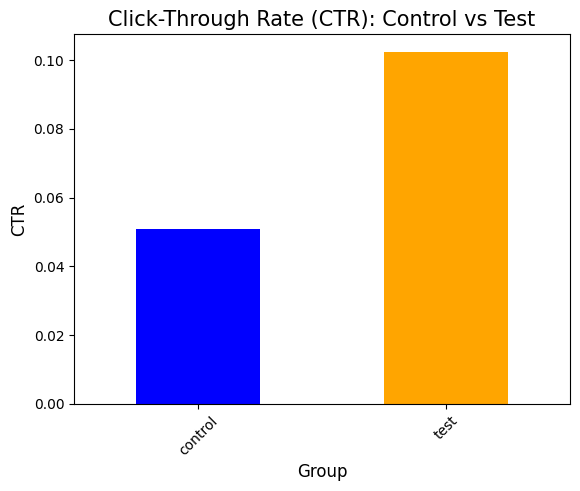

Insight: 
The test campaign shows significantly higher CTR, indicating stronger user engagement.


In [50]:
CTR_data = df.groupby('group')['CTR'].mean()

plt.figure()
CTR_data.plot(kind = 'bar', color = ['blue', 'orange'])

plt.title('Click-Through Rate (CTR): Control vs Test',fontsize = 15)
plt.xlabel('Group', fontsize = 12 )
plt.ylabel('CTR', fontsize = 12 )
plt.xticks(rotation = 45)

plt.show()

print("Insight: \nThe test campaign shows significantly higher CTR, indicating stronger user engagement.")


**2. Conversion Rate Comparison (Funnel Quality)**

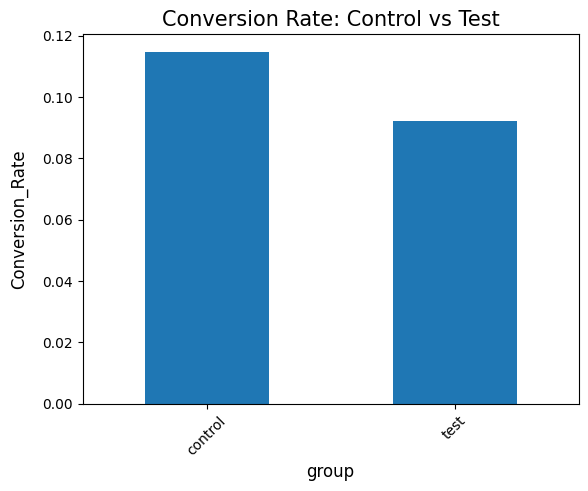

Insight : 
 The control campaign has a higher conversion rate, indicating better traffic quality and funnel performance


In [51]:
conversion_data = df.groupby('group')['Conversion_Rate'].mean()

plt.figure()
conversion_data.plot(kind='bar')

plt.title("Conversion Rate: Control vs Test", fontsize =15)
plt.xlabel("group", fontsize = 12)
plt.ylabel("Conversion_Rate", labelpad=10, fontsize = 12)

plt.xticks(rotation = 45)

plt.show()

print("Insight : \n The control campaign has a higher conversion rate, indicating better traffic quality and funnel performance")

**3. Cost per purchase Comparison**

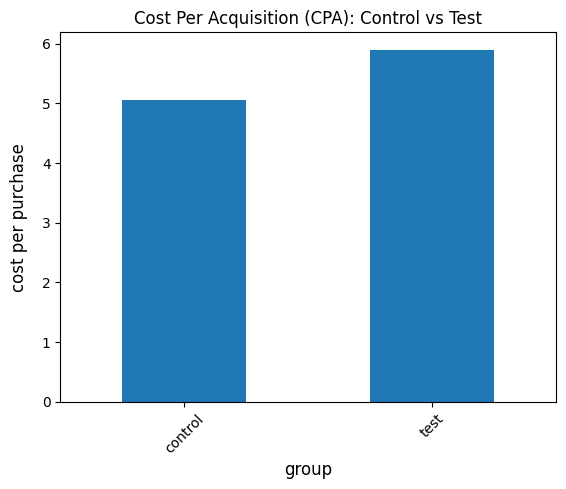

Insight:
The control campaign achieves a lower cost per acquisition, making it more cost-efficient.


In [52]:
cost_per_purchase_data = df.groupby('group')['cost_per_purchase'].mean()

plt.Figure()
cost_per_purchase_data.plot(kind='bar')

plt.title('Cost Per Acquisition (CPA): Control vs Test') 
plt.xlabel("group", fontsize = 12)
plt.ylabel("cost per purchase",labelpad=10 ,fontsize = 12)

plt.xticks(rotation = 45)
plt.show()

print ("Insight:\nThe control campaign achieves a lower cost per acquisition, making it more cost-efficient.")

In [53]:
cost_per_purchase_data.head()

group
control    5.052339
test       5.899589
Name: cost_per_purchase, dtype: float64


what i did here is,  i created 2 lists one for control group and one for test group and 
in each list i added the total number of clicks, impressions, add to cart and purchase for each group by filtering the data frame based on the group column and
then summing up the respective columns for each metric.

 these coloums clicks, impressions, add_to_cart, purchase represnt the different stages of customer journey in the funnel, and by summing them up for each group, we can analyze the performance of the control and test campaigns at each stage of the funnel.


In [54]:
control_funnel = [
    df[df['group']=='control']['impressions'].sum(),
    df[df['group']=='control']['clicks'].sum(),
    df[df['group']=='control']['add_to_cart'].sum(),
    df[df['group']=='control']['purchase'].sum()
]

test_funnel = [
    df[df['group']=='test']['impressions'].sum(),
    df[df['group']=='test']['clicks'].sum(),
    df[df['group']=='test']['add_to_cart'].sum(),
    df[df['group']=='test']['purchase'].sum()
]

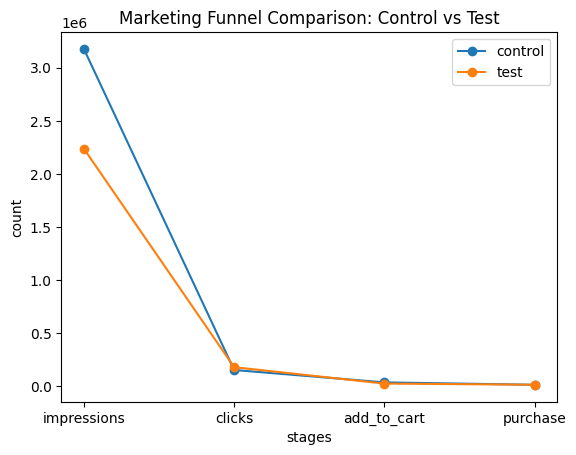

In [55]:
stages = ['impressions', 'clicks', 'add_to_cart', 'purchase']

plt.figure()

plt.plot(stages, control_funnel, marker ='o', label = 'control')
plt.plot(stages, test_funnel,marker = 'o', label ='test')

plt.title("Marketing Funnel Comparison: Control vs Test")

plt.xlabel("stages")
plt.ylabel('count')

plt.legend()
plt.show()


**Insight:**

The control campaign consistently retains more users across all funnel stages, from impressions to final purchase.

While the test campaign generates engagement, it experiences a higher drop-off after the click stage, indicating weaker conversion efficiency.

This suggests that although the test campaign attracts users, it fails to convert them effectively compared to the control campaign.

From a business perspective, the control campaign is more effective as it not only attracts users but also converts them more efficiently, resulting in better overall performance and lower acquisition cost.